In [1]:
#importing all libraries


import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import pymc as pm
import pytensor.tensor as pt
import arviz as az

from sklearn.preprocessing import StandardScaler


az.style.use('arviz-darkgrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#2E86AB', '#E84855', '#3BB273', '#F9A03F', '#7B2D8B']


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"PyMC version  : {pm.__version__}")
print(f"ArviZ version : {az.__version__}")

PyMC version  : 5.28.1
ArviZ version : 0.22.0


In [2]:
#loading data from kaggle, Telco-customer-churn

URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df_raw = pd.read_csv(URL)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# For the summary of data types and checking if there are missing values in the data

print(df_raw.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

Series([], dtype: int64)


## Exploratory Data Analysis (EDA)

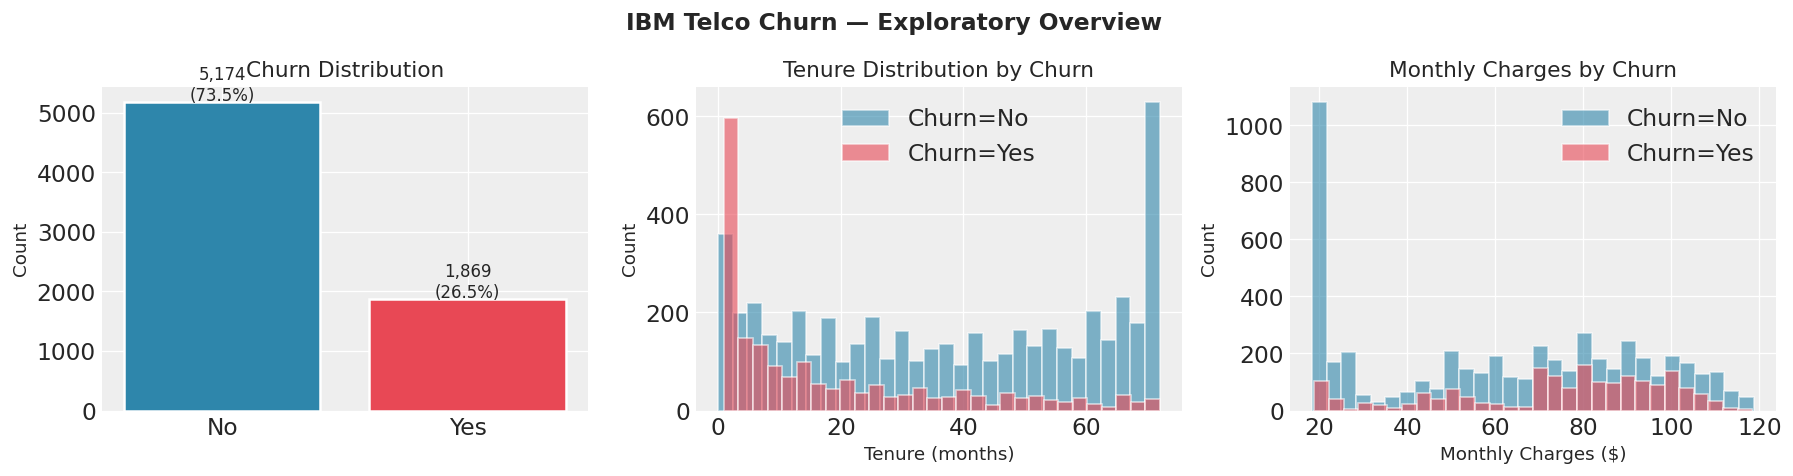


Overall churn rate: 26.5%
Median tenure (churned): 10 months
Median tenure (retained): 38 months


In [6]:
# Exploratory Data Analysis

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('IBM Telco Churn — Exploratory Overview', fontsize=14, fontweight='bold')

# Churn distribution
churn_counts = df_raw['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=PALETTE[:2], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df_raw)*100:.1f}%)', ha='center', fontsize=10)

#  Tenure distribution by churn status
for label, color in zip(['No', 'Yes'], PALETTE[:2]):
    subset = df_raw[df_raw['Churn'] == label]['tenure']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}', edgecolor='white')
axes[1].set_title('Tenure Distribution by Churn')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Count')
axes[1].legend()

#  Monthly charges by churn
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
for label, color in zip(['No', 'Yes'], PALETTE[:2]):
    subset = df_raw[df_raw['Churn'] == label]['MonthlyCharges']
    axes[2].hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}', edgecolor='white')
axes[2].set_title('Monthly Charges by Churn')
axes[2].set_xlabel('Monthly Charges ($)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nOverall churn rate: {(df_raw['Churn']=='Yes').mean()*100:.1f}%")
print(f"Median tenure (churned): {df_raw[df_raw['Churn']=='Yes']['tenure'].median():.0f} months")
print(f"Median tenure (retained): {df_raw[df_raw['Churn']=='No']['tenure'].median():.0f} months")

---
## Core Survival Analysis Concepts

Before building models, here is the theory.

### Time, Events, and Censoring

Let $T$ be the random variable representing the **time until churn**.

For each customer $i$, we observe:
- $t_i$ — the observed time (tenure in months)
- $\delta_i \in \{0, 1\}$ — event indicator: **1 = churned**, **0 = censored** (still active)

**Censoring** is critical. A customer who hasn't churned after 24 months is *not* missing data — they are a **right-censored observation**. They contribute real information: we know they survived *at least* 24 months.

Ignoring censored observations would severely **overestimate churn risk**.

### The Survival Function S(t)

$$S(t) = P(T > t)$$

The probability a customer survives (stays subscribed) beyond time $t$.

- $S(0) = 1$ — everyone starts as a customer
- $S(\infty) = 0$ — everyone eventually churns (in theory)
- $S(t)$ is monotonically decreasing

### The Hazard Function h(t)

$$h(t) = \lim_{\Delta t \to 0} \frac{P(t \leq T < t + \Delta t \mid T \geq t)}{\Delta t}$$

The **instantaneous rate** of churning at time $t$, given the customer has survived to $t$. Think of it as the "churn intensity" at any moment.

### Relationship Between S(t) and h(t)

$$S(t) = \exp\left(-\int_0^t h(u)\, du\right) = \exp(-H(t))$$

Where $H(t) = \int_0^t h(u)\, du$ is the **cumulative hazard function**.

###  The Likelihood for Censored Data

The likelihood contribution of each observation is:

$$L_i = [f(t_i)]^{\delta_i} \cdot [S(t_i)]^{1 - \delta_i}$$

- **If churned** ($\delta_i = 1$): contributes the PDF $f(t_i)$ — the probability of churning exactly at $t_i$
- **If censored** ($\delta_i = 0$): contributes $S(t_i)$ — the probability of surviving at least until $t_i$

This is the foundation that all three of our models are built on.

---
## Data Preprocessing

In [7]:
# making a copy of the data
df = df_raw.copy()

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

# Survival analysis targets
t_obs = df['tenure'].values.astype(float)          # time variable
event = (df['Churn'] == 'Yes').astype(int).values  # 1 = churned, 0 = censored

# Adding small epsilon to avoid log(0) issues
t_obs = np.where(t_obs == 0, 0.5, t_obs)

print(f"Observations : {len(t_obs):,}")
print(f"Events (churn): {event.sum():,} ({event.mean()*100:.1f}%)")
print(f"Censored     : {(1-event).sum():,} ({(1-event).mean()*100:.1f}%)")
print(f"Time range   : {t_obs.min():.1f} – {t_obs.max():.1f} months")

Observations : 7,032
Events (churn): 1,869 (26.6%)
Censored     : 5,163 (73.4%)
Time range   : 1.0 – 72.0 months


In [8]:
# Feature Engineering
# Contract type → ordinal encoding (higher = longer commitment = lower churn risk)

contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['contract_enc'] = df['Contract'].map(contract_map)

# Internet service → ordinal
internet_map = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
df['internet_enc'] = df['InternetService'].map(internet_map)

# Binary features
df['tech_support_enc'] = (df['TechSupport'] == 'Yes').astype(int)
df['paperless_enc']    = (df['PaperlessBilling'] == 'Yes').astype(int)
df['senior_enc']       = df['SeniorCitizen'].astype(int)

# Continuous features
scaler = StandardScaler()
monthly_scaled = scaler.fit_transform(df[['MonthlyCharges']]).ravel()

# Covariate matrix for Cox model
covariate_names = ['Monthly Charges', 'Contract Type', 'Tech Support',
                   'Internet Service', 'Paperless Billing', 'Senior Citizen']

X = np.column_stack([
    monthly_scaled,
    df['contract_enc'].values,
    df['tech_support_enc'].values,
    df['internet_enc'].values,
    df['paperless_enc'].values,
    df['senior_enc'].values,
])

n_obs, n_covs = X.shape
print(f"Covariate matrix: {X.shape}")
print(f"Covariates: {covariate_names}")

Covariate matrix: (7032, 6)
Covariates: ['Monthly Charges', 'Contract Type', 'Tech Support', 'Internet Service', 'Paperless Billing', 'Senior Citizen']


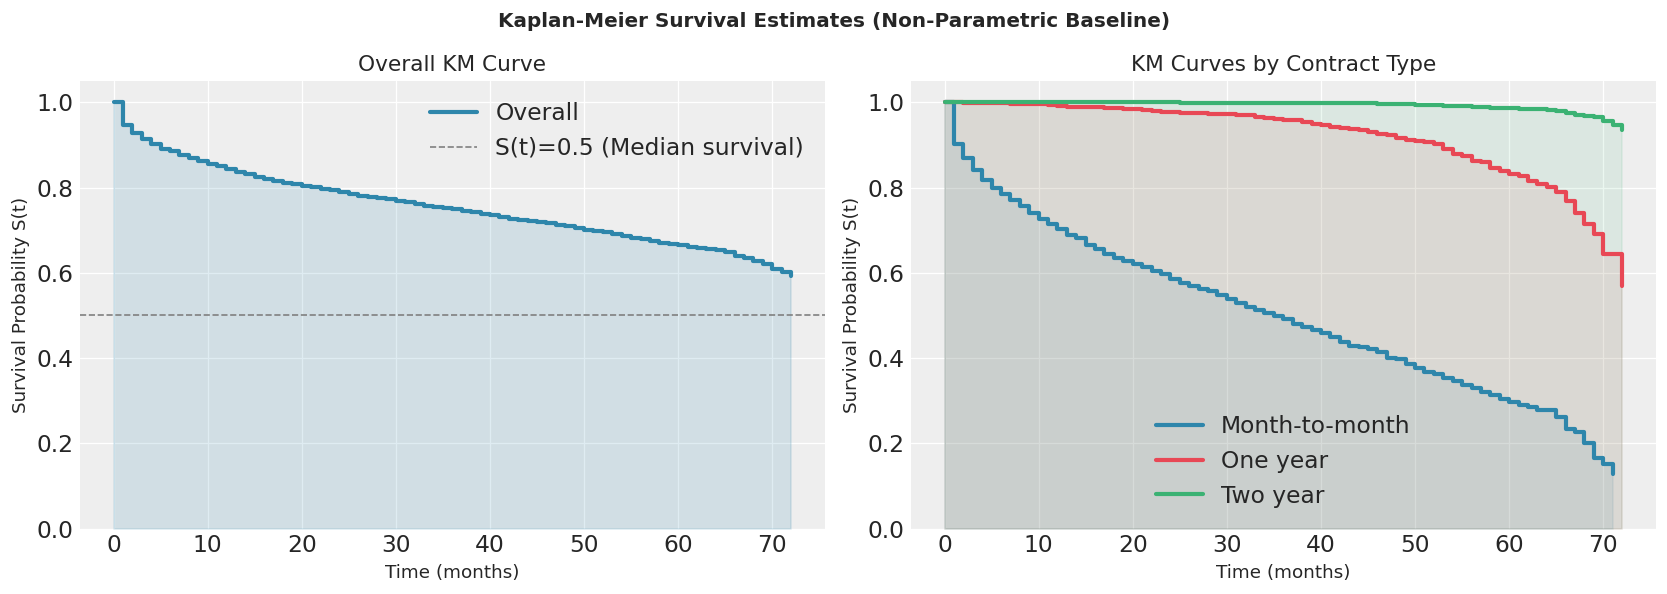

In [9]:
# Kaplan-Meier Estimate (Non-Parametric Baseline)
# I will compute KM manually to visualize the empirical survival curve
# This gives a model-free reference for the three Bayesian models.

def kaplan_meier(t, event):
    """Compute Kaplan-Meier survival function."""
    unique_times = np.sort(np.unique(t[event == 1]))
    survival = 1.0
    times, surv_probs = [0], [1.0]
    n = len(t)

    for ti in unique_times:
        at_risk = np.sum(t >= ti)
        events_at_ti = np.sum((t == ti) & (event == 1))
        survival *= (1 - events_at_ti / at_risk)
        times.append(ti)
        surv_probs.append(survival)

    return np.array(times), np.array(surv_probs)

km_times, km_surv = kaplan_meier(t_obs, event)

# KM by contract type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kaplan-Meier Survival Estimates (Non-Parametric Baseline)', fontweight='bold')

# Overall KM
axes[0].step(km_times, km_surv, where='post', color=PALETTE[0], lw=2.5, label='Overall')
axes[0].fill_between(km_times, km_surv, step='post', alpha=0.15, color=PALETTE[0])
axes[0].axhline(0.5, color='grey', ls='--', lw=1, label='S(t)=0.5 (Median survival)')
axes[0].set_xlabel('Time (months)')
axes[0].set_ylabel('Survival Probability S(t)')
axes[0].set_title('Overall KM Curve')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# By contract type
contract_labels = {0: 'Month-to-month', 1: 'One year', 2: 'Two year'}
for k, (label, color) in enumerate(zip(contract_labels.values(), PALETTE[:3])):
    mask = df['contract_enc'].values == k
    km_t, km_s = kaplan_meier(t_obs[mask], event[mask])
    axes[1].step(km_t, km_s, where='post', color=color, lw=2.5, label=label)
    axes[1].fill_between(km_t, km_s, step='post', alpha=0.1, color=color)

axes[1].set_xlabel('Time (months)')
axes[1].set_ylabel('Survival Probability S(t)')
axes[1].set_title('KM Curves by Contract Type')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

---
## Model 1 - Bayesian Exponential Survival Model

### The Exponential Distribution

The simplest parametric survival model assumes a **constant hazard rate** $\lambda > 0$:

$$h(t) = \lambda$$

This means the probability of churning in the next instant is the **same regardless of how long you've been a customer** — no memory. This is the *memoryless property* of the exponential distribution.

**Survival and PDF:**
$$S(t) = e^{-\lambda t} \qquad f(t) = \lambda e^{-\lambda t}$$

**Mean survival time:** $E[T] = 1/\lambda$

### Bayesian Formulation

We place a prior on $\lambda$ and condition on the observed data:

$$\lambda \sim \text{HalfNormal}(\sigma = 1)$$
$$T_i \sim \text{Exponential}(\lambda) \quad [\text{for churned customers}]$$
$$S(t_i | \lambda) \quad [\text{for censored customers}]$$

### Handling Censored Observations in PyMC

PyMC doesn't have a built-in censored likelihood, but we can construct it manually using `pm.Potential`. For a censored observation, we add $\log S(t_i)$ directly to the log-likelihood:

$$\log L = \sum_{i:\delta_i=1} \log f(t_i) + \sum_{i:\delta_i=0} \log S(t_i)$$

In [11]:
# Model 1: Bayesian Exponential Survival

# Separating observed events and censored observations
t_event    = t_obs[event == 1]   # times of actual churn
t_censored = t_obs[event == 0]   # last observed times for still-active customers

with pm.Model() as exp_model:

    lam = pm.HalfNormal('lambda', sigma=1.0)

    obs = pm.Exponential('obs', lam=lam, observed=t_event)

    log_surv_censored = pm.Potential(
        'censored_contribution',
        -lam * t_censored
    )

print("Exponential model structure:")
print('Free RVs  :', [rv.name for rv in exp_model.free_RVs])
print('Potentials:', [p.name for p in exp_model.potentials])
print('Observed  :', [rv.name for rv in exp_model.observed_RVs])

Exponential model structure:
Free RVs  : ['lambda']
Potentials: ['censored_contribution']
Observed  : ['obs']


In [12]:
# Sample from the Exponential model
with exp_model:
    trace_exp = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.90,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )

print("\n Exponential Model Posterior Summary ")
az.summary(trace_exp, var_names=['lambda'], round_to=4)

Output()


 Exponential Model Posterior Summary 


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda,0.0082,0.0002,0.0079,0.0086,0.0,0.0,3076.1683,4381.8251,1.0002


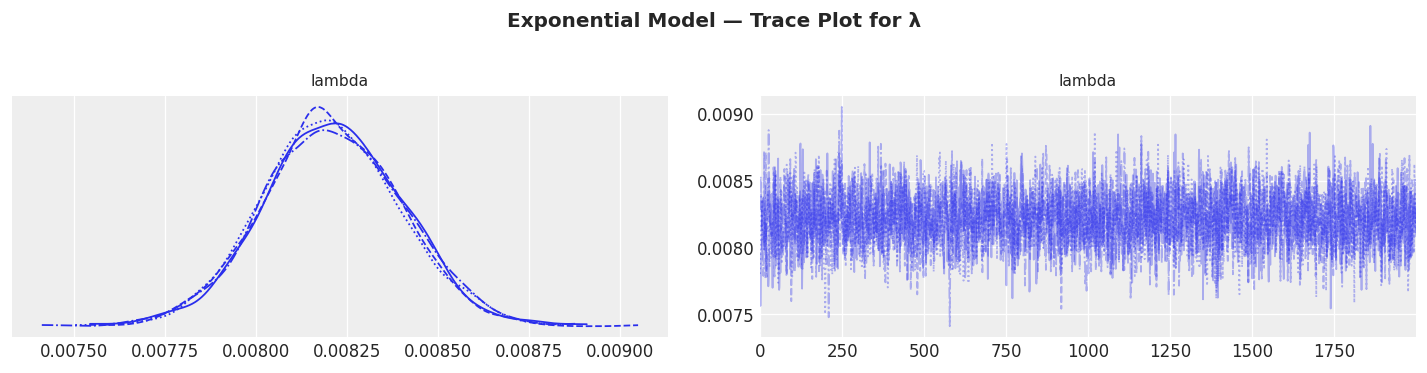


Convergence diagnostics:


,mean,sd,r_hat,ess_bulk
lambda,0.0082,0.0002,1.0002,3076.1683


In [13]:
# Trace Plot
# Trace plots show two things:
#   LEFT: Posterior distribution of the parameter
#   RIGHT: MCMC chain trajectory

az.plot_trace(trace_exp, var_names=['lambda'], figsize=(12, 3))
plt.suptitle('Exponential Model — Trace Plot for λ', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

#  Diagnostics
# R-hat: should be ≈1.0 (chains converged)
# ESS: effective sample size, higher is better
print("\nConvergence diagnostics:")
az.summary(trace_exp, var_names=['lambda'], round_to=4)[['mean','sd','r_hat','ess_bulk']]

In [14]:
# Posterior Predictive: Survival Curve
t_grid = np.linspace(0, 72, 300)  # 0 to 72 months

# Extracting posterior samples of lambda
lam_samples = trace_exp.posterior['lambda'].values.ravel()  # shape: (chains * draws,)

# Compute S(t) = exp(-lambda * t) for each posterior draw
# Result shape: (n_samples, n_timepoints)
surv_exp = np.exp(-np.outer(lam_samples, t_grid))

surv_exp_mean = surv_exp.mean(axis=0)
surv_exp_lower = np.percentile(surv_exp, 2.5, axis=0)
surv_exp_upper = np.percentile(surv_exp, 97.5, axis=0)

# Also compute hazard: h(t) = lambda (constant for exponential)
lam_mean = lam_samples.mean()
hazard_exp = np.full_like(t_grid, lam_mean)

print(f"Posterior mean λ = {lam_mean:.4f}")
print(f"Implied mean survival time = {1/lam_mean:.1f} months")
print(f"Implied median survival time = {np.log(2)/lam_mean:.1f} months")

Posterior mean λ = 0.0082
Implied mean survival time = 121.8 months
Implied median survival time = 84.4 months


In [17]:
# Computing WAIC and LOO for Exponential Model
# I need log-likelihood for WAIC/LOO
# I'll compute and attach it using pm.compute_log_likelihood

waic_exp = az.waic(trace_exp)
loo_exp  = az.loo(trace_exp)
print("Exponential Model — WAIC:", waic_exp.elpd_waic.round(2))
print("Exponential Model — LOO :", loo_exp.elpd_loo.round(2))

Exponential Model — WAIC: -9252.65
Exponential Model — LOO : -9252.65


---
##  Model 2 — Bayesian Weibull Survival Model

### Why Go Beyond Exponential?

The exponential model's constant hazard is often unrealistic. In practice:
- New customers may be at higher churn risk initially (onboarding friction)
- Long-tenure customers may become more loyal over time (decreasing hazard)

The **Weibull distribution** introduces a **shape parameter** $\alpha$ that lets the hazard vary with time.

### Weibull Parameterization

$$h(t) = \frac{\alpha}{\beta} \left(\frac{t}{\beta}\right)^{\alpha - 1}$$

$$S(t) = \exp\left[- \left(\frac{t}{\beta}\right)^{\alpha}\right]$$

Where:
- $\alpha > 0$ is the **shape** parameter
- $\beta > 0$ is the **scale** parameter (characteristic life)

**Interpretation of $\alpha$:**

| Value | Hazard Shape | Customer Behavior |
|-------|-------------|--------------------|
| $\alpha < 1$ | Decreasing | Early churners leave fast; survivors become loyal |
| $\alpha = 1$ | Constant | Reduces to Exponential model |
| $\alpha > 1$ | Increasing | Churn accelerates with time (e.g., price-sensitive customers) |

### Bayesian Priors

$$\alpha \sim \text{HalfNormal}(\sigma=2) \qquad \beta \sim \text{HalfNormal}(\sigma=100)$$

In [18]:
# Model 2: Bayesian Weibull Survival

with pm.Model() as weibull_model:

    # Priors
    alpha = pm.HalfNormal('alpha', sigma=2.0)
    beta  = pm.HalfNormal('beta', sigma=100.0)

    # Likelihood for observed events
    # Weibull log-pdf: log(alpha/beta) + (alpha-1)*log(t/beta) - (t/beta)^alpha
    obs = pm.Weibull('obs', alpha=alpha, beta=beta, observed=t_event)

    # Censored contribution: log S(t) = -(t/beta)^alpha
    log_surv_censored = pm.Potential(
        'censored_contribution',
        -(t_censored / beta) ** alpha
    )

# Sample
with weibull_model:
    trace_weibull = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.92,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )

print("\n Weibull Model Posterior Summary ")
az.summary(trace_weibull, var_names=['alpha', 'beta'], round_to=4)

Output()


 Weibull Model Posterior Summary 


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.6465,0.0132,0.6214,0.6711,0.0003,0.0002,2734.6535,3143.4092,1.0007
beta,218.6941,10.9706,198.1604,239.2114,0.2095,0.1553,2772.2884,3249.7827,1.0011


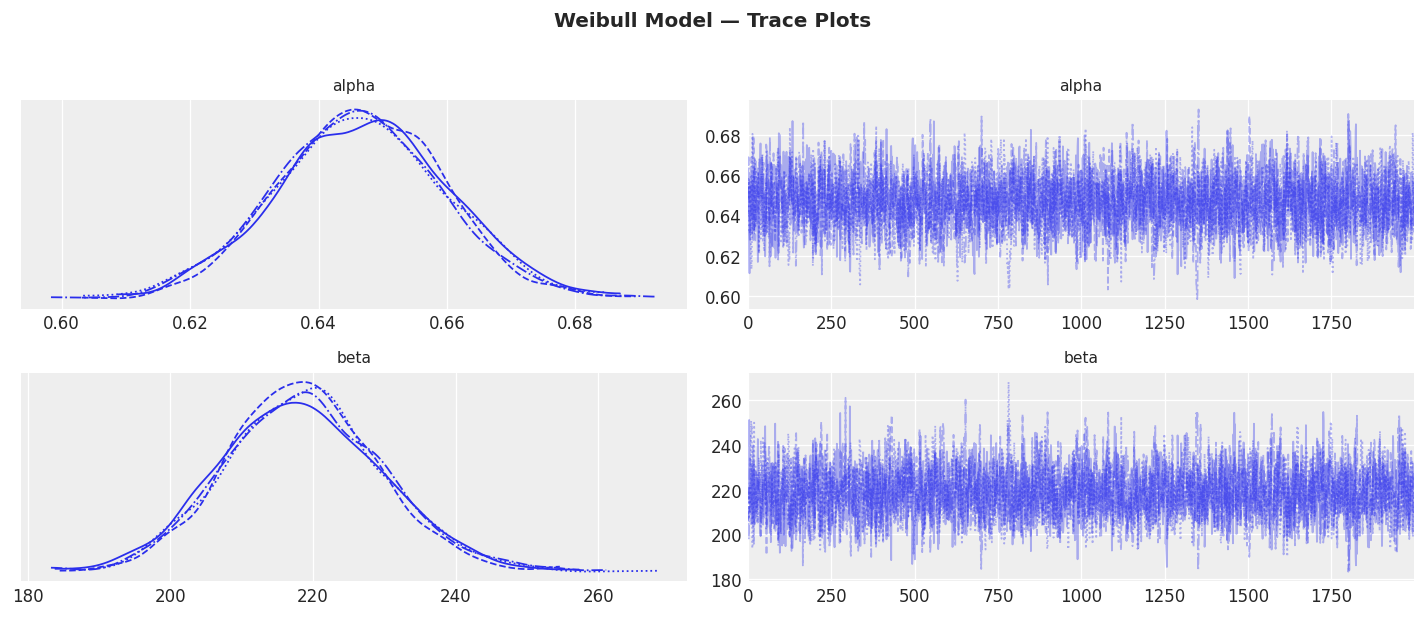


Posterior mean α = 0.647
Posterior mean β = 218.7 months

 α < 1: Decreasing hazard — early churners leave fast; long-tenure customers become more stable.


In [19]:
# Trace Plots
az.plot_trace(trace_weibull, var_names=['alpha', 'beta'], figsize=(12, 5))
plt.suptitle('Weibull Model — Trace Plots', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# Posterior interpretation
alpha_samples = trace_weibull.posterior['alpha'].values.ravel()
beta_samples  = trace_weibull.posterior['beta'].values.ravel()

alpha_mean = alpha_samples.mean()
beta_mean  = beta_samples.mean()

print(f"\nPosterior mean α = {alpha_mean:.3f}")
print(f"Posterior mean β = {beta_mean:.1f} months")

if alpha_mean < 1:
    print("\n α < 1: Decreasing hazard — early churners leave fast; long-tenure customers become more stable.")
elif alpha_mean > 1:
    print("\n  α > 1: Increasing hazard — churn risk grows with tenure (unusual for telco).")
else:
    print("\nα ≈ 1: Constant hazard — Weibull reduces to Exponential model.")

In [22]:
# Posterior Predictive Survival & Hazard for Weibull
t_rep = t_grid[None, :]         # (1, T)
a_rep = alpha_samples[:, None]  # (S, 1)
b_rep = beta_samples[:, None]   # (S, 1)

# S(t) = exp(-(t/beta)^alpha)
surv_weibull = np.exp(-(t_rep / b_rep) ** a_rep)

surv_weibull_mean  = surv_weibull.mean(axis=0)
surv_weibull_lower = np.percentile(surv_weibull, 2.5, axis=0)
surv_weibull_upper = np.percentile(surv_weibull, 97.5, axis=0)

# Hazard: h(t) = (alpha/beta) * (t/beta)^(alpha-1)
hazard_weibull = (alpha_mean / beta_mean) * (t_grid / beta_mean) ** (alpha_mean - 1)

# WAIC and LOO
waic_weibull = az.waic(trace_weibull)
loo_weibull  = az.loo(trace_weibull)
print("Weibull Model — WAIC:", waic_weibull.elpd_waic.round(2))
print("Weibull Model — LOO :", loo_weibull.elpd_loo.round(2))

Weibull Model — WAIC: -9025.02
Weibull Model — LOO : -9025.02


---
## Model 3 — Bayesian Cox Proportional Hazards Model

### What Is the Cox Model?

The two previous models explain *how long* customers survive on average, but they don't tell us *which covariates* drive churn. The **Cox Proportional Hazards (Cox PH)** model is the most widely used survival model precisely because it incorporates covariates.

### Model Specification

$$h(t | \mathbf{x}_i) = h_0(t) \cdot \exp(\boldsymbol{\beta}^\top \mathbf{x}_i)$$

Where:
- $h_0(t)$ is the **baseline hazard** (the hazard when all covariates = 0)
- $\mathbf{x}_i$ is the covariate vector for customer $i$
- $\boldsymbol{\beta}$ are the **log-hazard ratios** (what we want to learn)

### The "Proportional" Assumption

The covariate effect is **multiplicative** and **constant** over time. Customer A always has $e^{\beta_j}$ times the hazard of Customer B (who differs only on covariate $j$), regardless of time.

### Interpreting Coefficients

| $\beta_j$ | $e^{\beta_j}$ | Meaning |
|-----------|--------------|----------|
| $> 0$ | $> 1$ | Covariate **increases** churn risk |
| $= 0$ | $= 1$ | No effect |
| $< 0$ | $< 1$ | Covariate **decreases** churn risk (protective) |

### Bayesian Cox PH in PyMC

We use a **Weibull baseline hazard** (making this a parametric Cox model), with Normal priors on the $\beta$ coefficients:

$$\beta_j \sim \mathcal{N}(0, 1)$$

This acts as mild regularization, shrinking small effects toward zero.

In [23]:
# Model 3: Bayesian Cox PH with Weibull Baseline

X_event    = X[event == 1]
X_censored = X[event == 0]

with pm.Model() as cox_model:

    # Baseline Weibull parameters
    alpha0 = pm.HalfNormal('alpha0', sigma=2.0)   # baseline shape
    beta0  = pm.HalfNormal('beta0',  sigma=100.0) # baseline scale

    # Covariate coefficients (log-hazard ratios)
    # Normal(0,1) prior = mild regularization
    betas = pm.Normal('betas', mu=0, sigma=1, shape=n_covs)

    # Linear predictor: xb = X @ betas
    # exp(xb) is the hazard ratio relative to baseline
    xb_event    = pt.dot(X_event,    betas)   # (n_events,)
    xb_censored = pt.dot(X_censored, betas)   # (n_censored,)

    # Effective scale per individual
    # In Weibull PH: the covariate shifts the scale
    # beta_eff = beta0 * exp(-xb / alpha0)
    beta_eff_event    = beta0 * pt.exp(-xb_event    / alpha0)
    beta_eff_censored = beta0 * pt.exp(-xb_censored / alpha0)

    # Likelihood for events
    obs = pm.Weibull('obs', alpha=alpha0, beta=beta_eff_event, observed=t_event)

    # Censored contribution
    log_surv_censored = pm.Potential(
        'censored_contribution',
        -(t_censored / beta_eff_censored) ** alpha0
    )

# Sample
with cox_model:
    trace_cox = pm.sample(
        draws=2000,
        tune=1500,
        chains=4,
        target_accept=0.95,   # higher acceptance for complex model
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )

print("\n Cox PH Model Posterior Summary ")
az.summary(trace_cox, var_names=['alpha0', 'beta0', 'betas'], round_to=4)

Output()


 Cox PH Model Posterior Summary 


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha0,0.8415,0.0157,0.8118,0.8710,0.0002,0.0002,7420.4140,5709.9887,0.9999
beta0,335.3786,43.6862,256.9628,419.5623,0.7145,0.4797,3718.1799,4967.3588,1.0004
betas[0],-0.7461,0.0563,-0.8523,-0.6444,0.0009,0.0006,3913.3171,5179.0973,1.0010
betas[1],-1.6542,0.0588,-1.7600,-1.5390,0.0007,0.0007,7890.4042,5298.5310,1.0002
betas[2],-0.3567,0.0637,-0.4734,-0.2332,0.0007,0.0008,8038.3334,5354.2819,1.0009
betas[3],1.1609,0.0742,1.0192,1.2990,0.0012,0.0008,3630.8167,4677.0488,1.0006
betas[4],0.1703,0.0548,0.0698,0.2729,0.0006,0.0006,7612.0270,5601.4294,1.0009
betas[5],-0.0804,0.0543,-0.1847,0.0186,0.0006,0.0007,9571.5077,5731.8834,1.0002


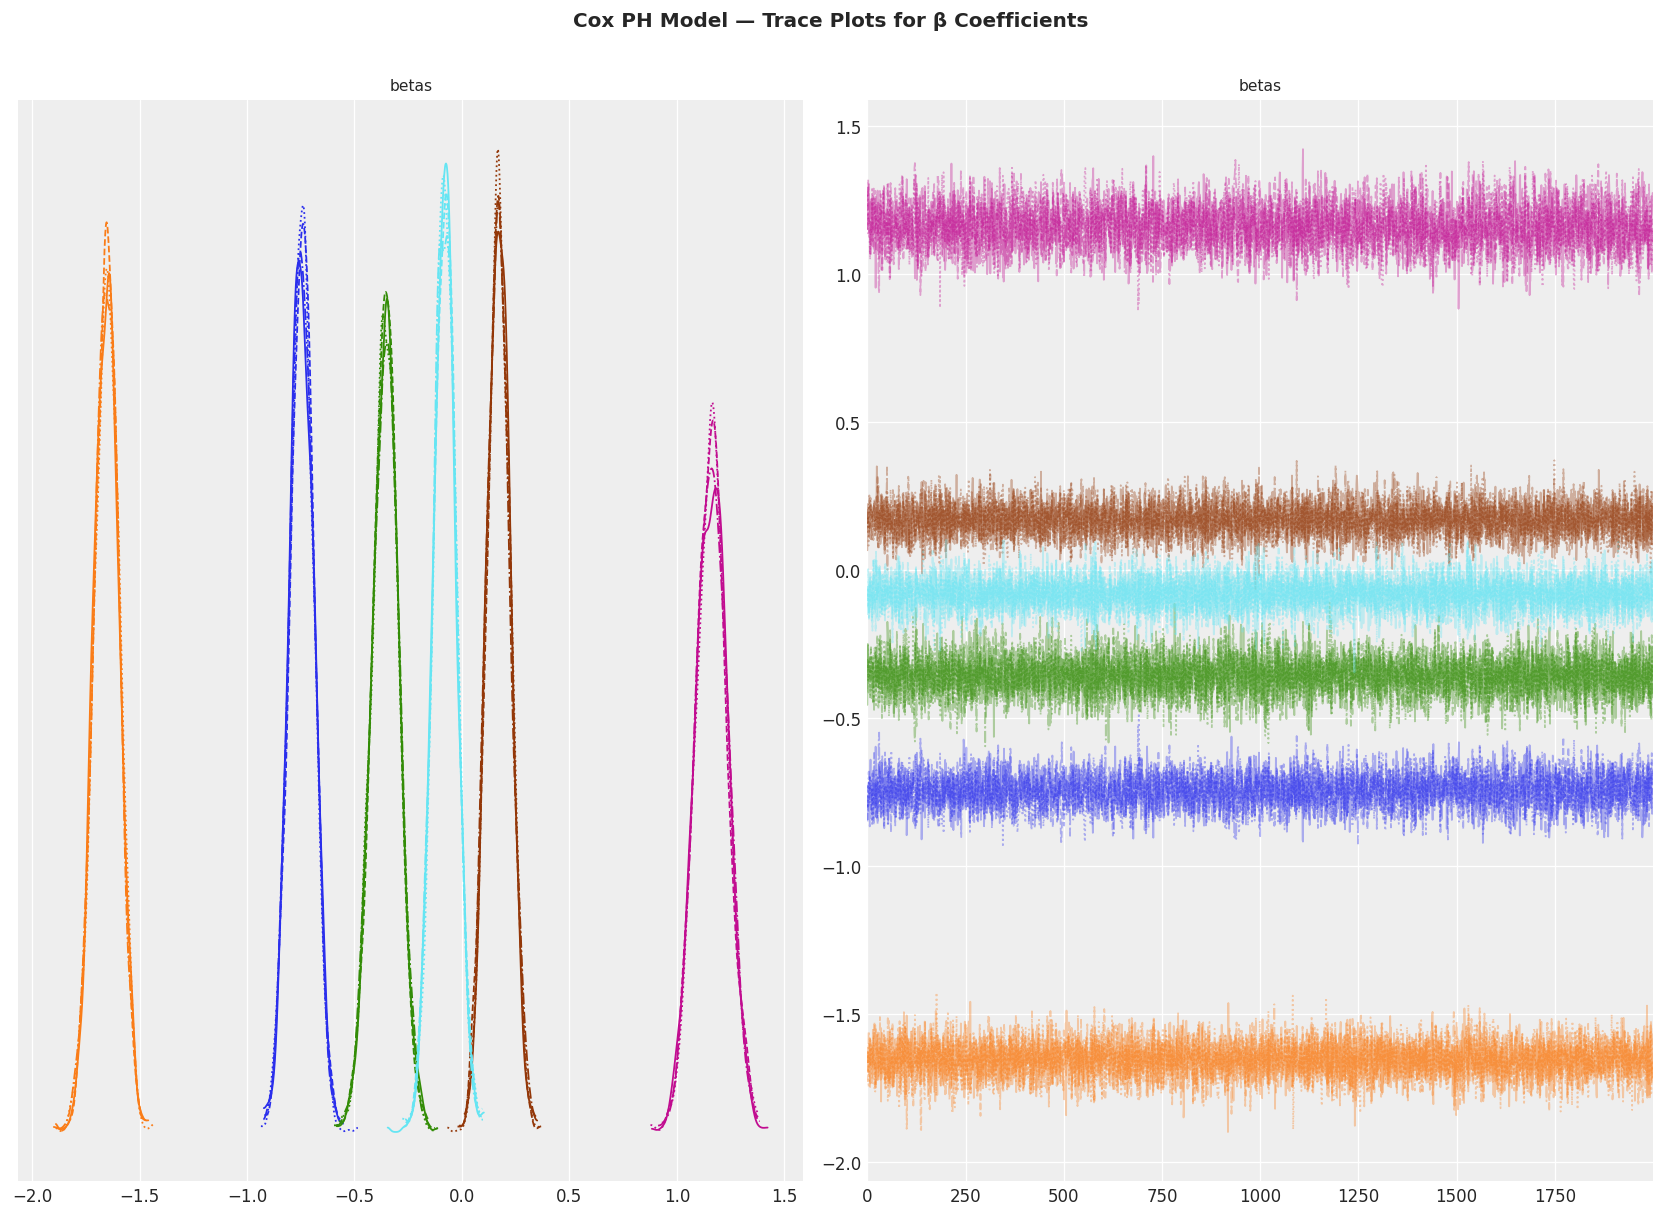

In [24]:
# Trace Plots for Cox Model
az.plot_trace(trace_cox, var_names=['betas'], figsize=(14, 10),
              combined=False)
plt.suptitle('Cox PH Model — Trace Plots for β Coefficients', y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

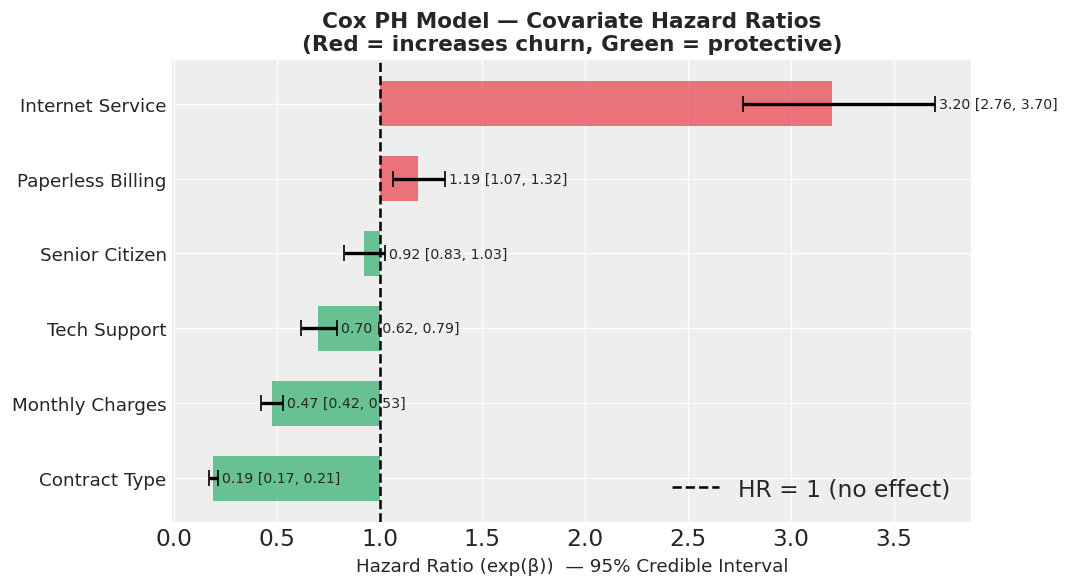

In [25]:
# Covariate Effect Plot (Forest Plot of Hazard Ratios)
# Hazard Ratio = exp(beta_j)
# HR > 1 → increases churn risk
# HR < 1 → protective (reduces churn risk)

betas_samples = trace_cox.posterior['betas'].values.reshape(-1, n_covs)

# Compute hazard ratios
hr_samples = np.exp(betas_samples)   # (S, n_covs)

hr_mean  = hr_samples.mean(axis=0)
hr_lower = np.percentile(hr_samples, 2.5, axis=0)
hr_upper = np.percentile(hr_samples, 97.5, axis=0)

# Sort by HR magnitude
sort_idx = np.argsort(hr_mean)
names_sorted  = [covariate_names[i] for i in sort_idx]
hr_mean_s     = hr_mean[sort_idx]
hr_lower_s    = hr_lower[sort_idx]
hr_upper_s    = hr_upper[sort_idx]

fig, ax = plt.subplots(figsize=(9, 5))

y_pos = np.arange(n_covs)
colors_hr = [PALETTE[1] if m > 1 else PALETTE[2] for m in hr_mean_s]

ax.barh(y_pos, hr_mean_s - 1, left=1, color=colors_hr, alpha=0.75, height=0.6)
ax.errorbar(
    hr_mean_s, y_pos,
    xerr=[hr_mean_s - hr_lower_s, hr_upper_s - hr_mean_s],
    fmt='none', color='black', capsize=5, lw=2
)

# Reference line at HR=1 (no effect)
ax.axvline(1.0, color='black', ls='--', lw=1.5, label='HR = 1 (no effect)')

ax.set_yticks(y_pos)
ax.set_yticklabels(names_sorted, fontsize=11)
ax.set_xlabel('Hazard Ratio (exp(β))  — 95% Credible Interval', fontsize=11)
ax.set_title('Cox PH Model — Covariate Hazard Ratios\n(Red = increases churn, Green = protective)', fontweight='bold')

# Annotate values
for i, (mean, lo, hi) in enumerate(zip(hr_mean_s, hr_lower_s, hr_upper_s)):
    ax.text(hi + 0.02, i, f'{mean:.2f} [{lo:.2f}, {hi:.2f}]', va='center', fontsize=8.5)

ax.legend()
plt.tight_layout()
plt.show()

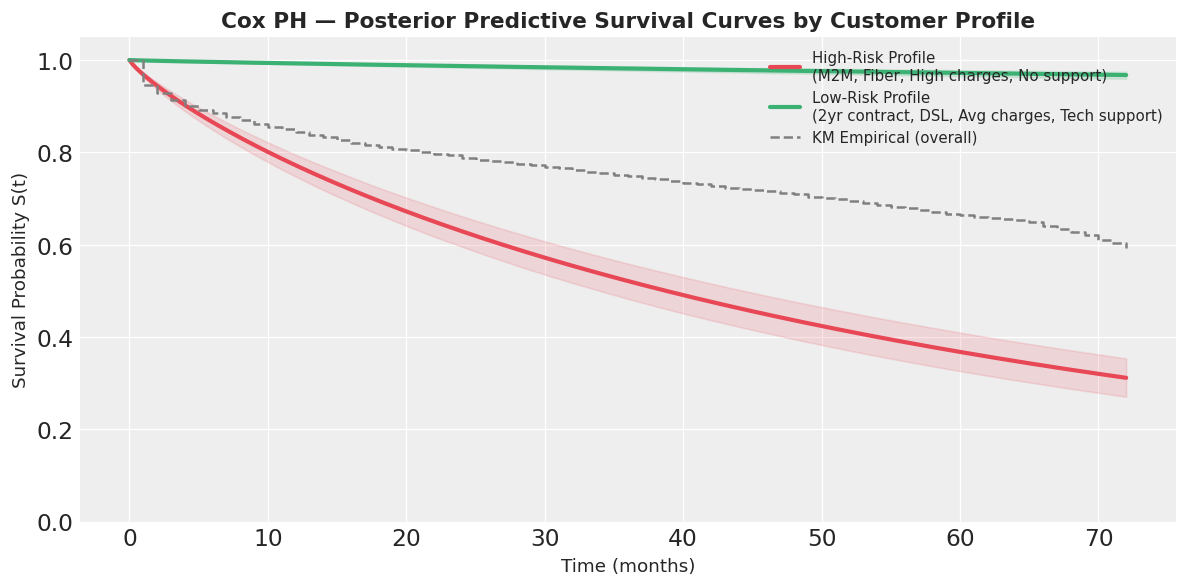

In [26]:
# Cox Model: Survival Curves for Covariate Profiles
# Compare survival for a "high-risk" vs "low-risk" customer profile

alpha0_samples = trace_cox.posterior['alpha0'].values.ravel()
beta0_samples  = trace_cox.posterior['beta0'].values.ravel()
betas_all      = trace_cox.posterior['betas'].values.reshape(-1, n_covs)

def cox_survival_curve(x_profile, alpha0_s, beta0_s, betas_s, t_grid):
    """Compute posterior survival curves for a covariate profile."""
    xb = betas_s @ x_profile                        # (S,)
    beta_eff = beta0_s * np.exp(-xb / alpha0_s)     # (S,)
    # S(t) = exp(-(t/beta_eff)^alpha0)
    surv = np.exp(-(t_grid[None, :] / beta_eff[:, None]) ** alpha0_s[:, None])
    return surv  # (S, T)

# Profile 1: HIGH RISK — Month-to-month, Fiber optic, high charges, no tech support
# [monthly_charges, contract, tech_support, internet, paperless, senior]
# scaler.transform([[90]]) ≈ 1.3
high_risk = np.array([1.3, 0, 0, 2, 1, 1])

# Profile 2: LOW RISK — Two-year contract, DSL, avg charges, tech support
low_risk  = np.array([-0.5, 2, 1, 1, 0, 0])

surv_high = cox_survival_curve(high_risk, alpha0_samples, beta0_samples, betas_all, t_grid)
surv_low  = cox_survival_curve(low_risk,  alpha0_samples, beta0_samples, betas_all, t_grid)

fig, ax = plt.subplots(figsize=(10, 5))

for surv, color, label in [
    (surv_high, PALETTE[1], 'High-Risk Profile\n(M2M, Fiber, High charges, No support)'),
    (surv_low,  PALETTE[2], 'Low-Risk Profile\n(2yr contract, DSL, Avg charges, Tech support)'),
]:
    mean  = surv.mean(axis=0)
    lower = np.percentile(surv, 2.5,  axis=0)
    upper = np.percentile(surv, 97.5, axis=0)
    ax.plot(t_grid, mean, color=color, lw=2.5, label=label)
    ax.fill_between(t_grid, lower, upper, color=color, alpha=0.15)

ax.step(km_times, km_surv, where='post', color='grey', lw=1.5, ls='--', label='KM Empirical (overall)')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival Probability S(t)')
ax.set_title('Cox PH — Posterior Predictive Survival Curves by Customer Profile', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [29]:
waic_cox = az.waic(trace_cox)
loo_cox  = az.loo(trace_cox)
print("Cox PH Model — WAIC:", waic_cox.elpd_waic.round(2))
print("Cox PH Model — LOO :", loo_cox.elpd_loo.round(2))

Cox PH Model — WAIC: -7960.72
Cox PH Model — LOO : -7960.72


---
##  All Models Together — Combined Visualizations

Now let's overlay all three models to compare their survival curves, hazard shapes, and fit statistics.

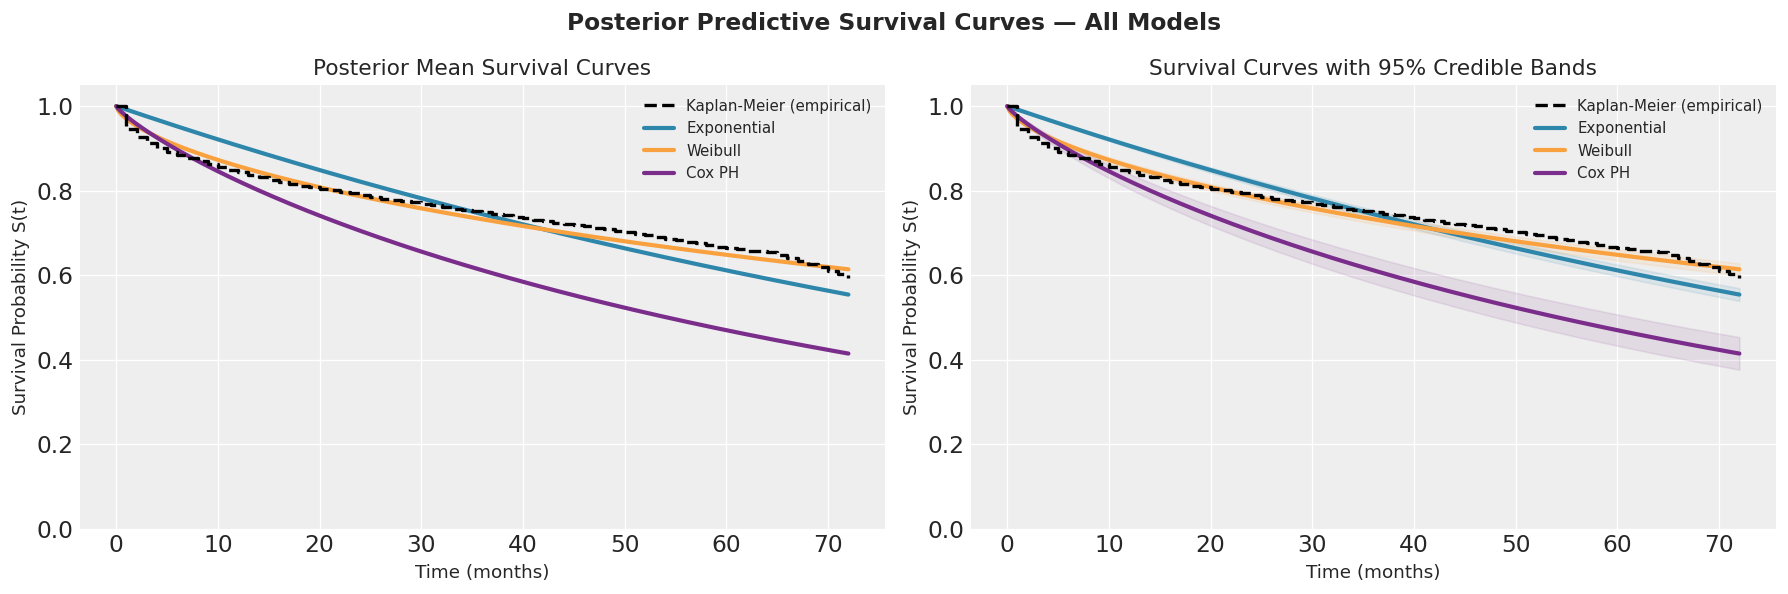

In [30]:
# Survival Curves Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Posterior Predictive Survival Curves — All Models', fontsize=14, fontweight='bold')

# Using Cox posterior mean profile (avg customer)
avg_profile = np.array([0.0, 0, 0, 1, 0, 0])
surv_cox_avg = cox_survival_curve(avg_profile, alpha0_samples, beta0_samples, betas_all, t_grid)

model_results = [
    ('Exponential', surv_exp,          PALETTE[0]),
    ('Weibull',     surv_weibull,       PALETTE[3]),
    ('Cox PH',      surv_cox_avg,       PALETTE[4]),
]

for ax_idx, ax in enumerate(axes):
    # KM reference
    ax.step(km_times, km_surv, where='post', color='black', lw=2,
            ls='--', label='Kaplan-Meier (empirical)', zorder=5)

    for name, surv_mat, color in model_results:
        mean  = surv_mat.mean(axis=0)
        lower = np.percentile(surv_mat, 2.5, axis=0)
        upper = np.percentile(surv_mat, 97.5, axis=0)
        ax.plot(t_grid, mean, color=color, lw=2.5, label=name)
        if ax_idx == 1:  # show CI only in right panel to avoid clutter
            ax.fill_between(t_grid, lower, upper, color=color, alpha=0.1)

    ax.set_xlabel('Time (months)')
    ax.set_ylabel('Survival Probability S(t)')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

axes[0].set_title('Posterior Mean Survival Curves')
axes[1].set_title('Survival Curves with 95% Credible Bands')

plt.tight_layout()
plt.show()

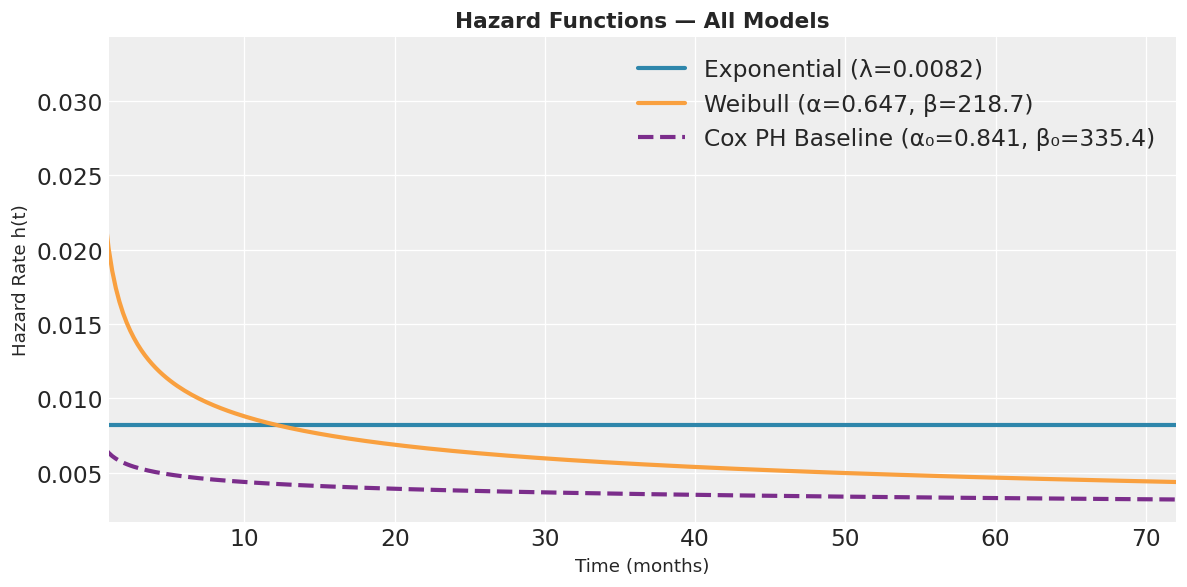

In [31]:
# Fig 2: Hazard Functions Comparison
fig, ax = plt.subplots(figsize=(10, 5))

# Exponential: constant hazard
ax.axhline(lam_mean, color=PALETTE[0], lw=2.5, label=f'Exponential (λ={lam_mean:.4f})')

# Weibull hazard
ax.plot(t_grid, hazard_weibull, color=PALETTE[3], lw=2.5,
        label=f'Weibull (α={alpha_mean:.3f}, β={beta_mean:.1f})')

# Cox baseline hazard (alpha0, beta0 posterior means)
alpha0_mean = alpha0_samples.mean()
beta0_mean  = beta0_samples.mean()
hazard_cox_baseline = (alpha0_mean / beta0_mean) * (t_grid / beta0_mean) ** (alpha0_mean - 1)
ax.plot(t_grid, hazard_cox_baseline, color=PALETTE[4], lw=2.5,
        label=f'Cox PH Baseline (α₀={alpha0_mean:.3f}, β₀={beta0_mean:.1f})', ls='--')

ax.set_xlabel('Time (months)')
ax.set_ylabel('Hazard Rate h(t)')
ax.set_title('Hazard Functions — All Models', fontweight='bold')
ax.legend()
ax.set_xlim(1, 72)
plt.tight_layout()
plt.show()

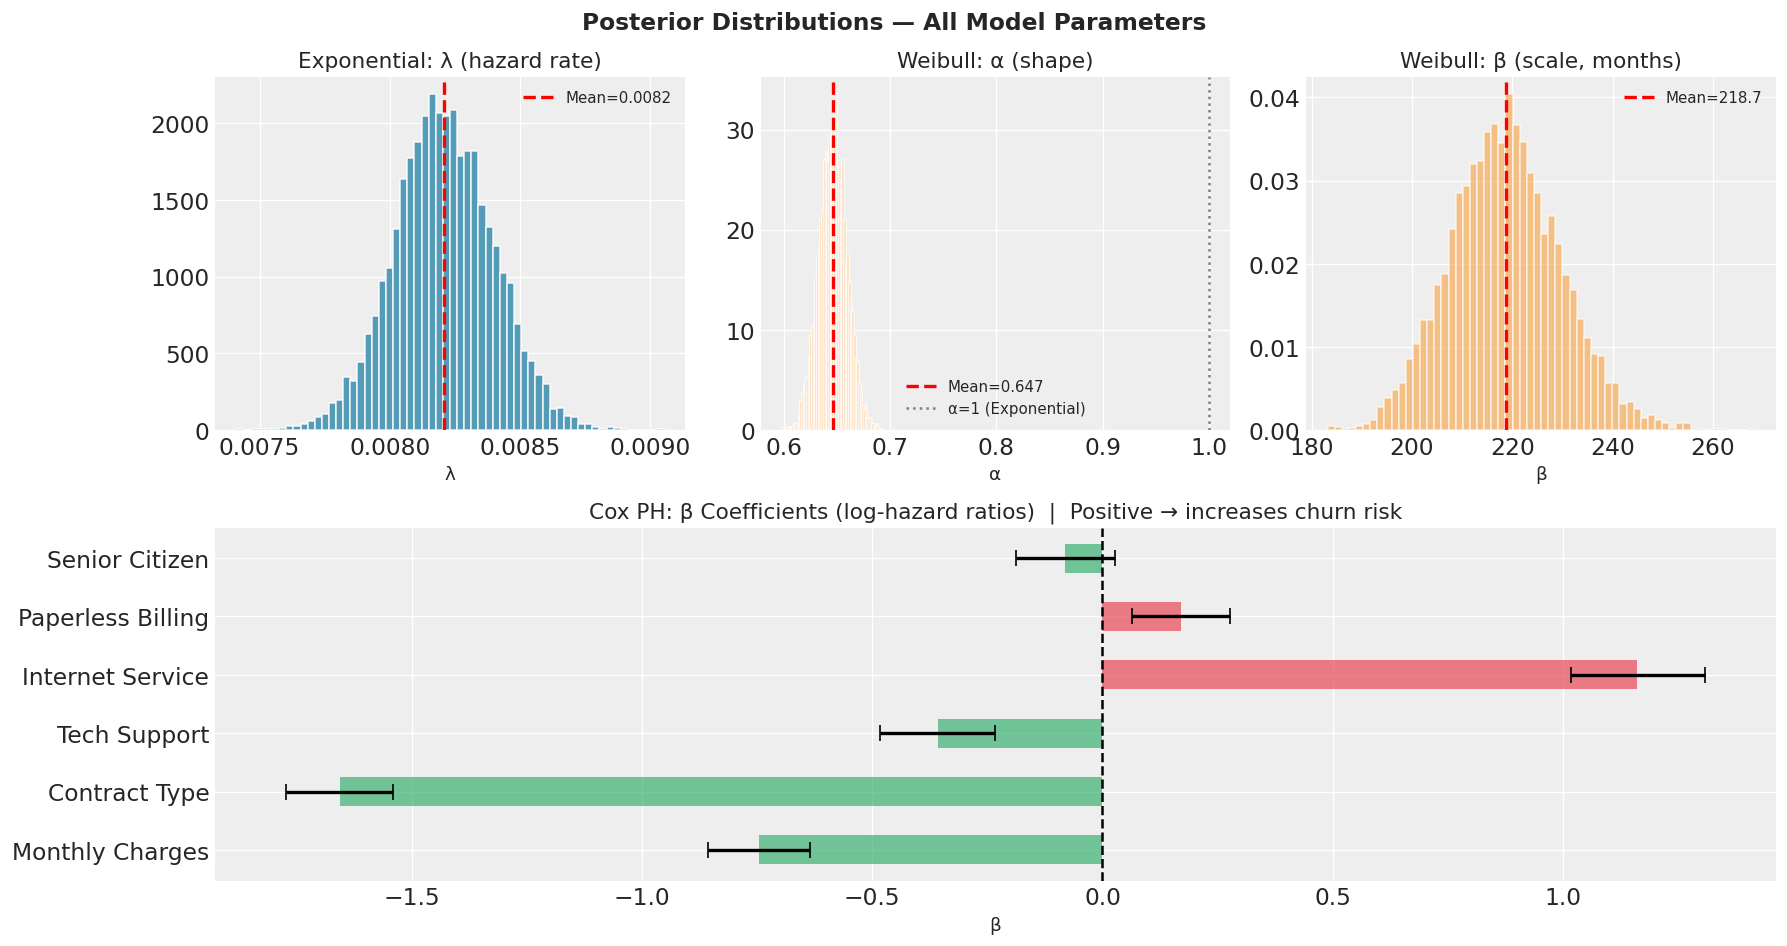

In [32]:
# Posterior Distributions (Combined)
fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle('Posterior Distributions — All Model Parameters', fontsize=14, fontweight='bold')

# Exponential: lambda
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(lam_samples, bins=60, color=PALETTE[0], alpha=0.8, edgecolor='white', density=True)
ax1.axvline(lam_samples.mean(), color='red', lw=2, ls='--', label=f'Mean={lam_samples.mean():.4f}')
ax1.set_title('Exponential: λ (hazard rate)')
ax1.set_xlabel('λ')
ax1.legend(fontsize=9)

# Weibull: alpha
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(alpha_samples, bins=60, color=PALETTE[3], alpha=0.8, edgecolor='white', density=True)
ax2.axvline(alpha_samples.mean(), color='red', lw=2, ls='--', label=f'Mean={alpha_samples.mean():.3f}')
ax2.axvline(1.0, color='grey', lw=1.5, ls=':', label='α=1 (Exponential)')
ax2.set_title('Weibull: α (shape)')
ax2.set_xlabel('α')
ax2.legend(fontsize=9)

# Weibull: beta
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(beta_samples, bins=60, color=PALETTE[3], alpha=0.6, edgecolor='white', density=True)
ax3.axvline(beta_samples.mean(), color='red', lw=2, ls='--', label=f'Mean={beta_samples.mean():.1f}')
ax3.set_title('Weibull: β (scale, months)')
ax3.set_xlabel('β')
ax3.legend(fontsize=9)

# Cox betas forest plot (bottom row spanning full width)
ax4 = fig.add_subplot(gs[1, :])
beta_means  = betas_all.mean(axis=0)
beta_lowers = np.percentile(betas_all, 2.5, axis=0)
beta_uppers = np.percentile(betas_all, 97.5, axis=0)

colors_b = [PALETTE[1] if m > 0 else PALETTE[2] for m in beta_means]
y_pos = np.arange(n_covs)
ax4.barh(y_pos, beta_means, color=colors_b, alpha=0.7, height=0.5)
ax4.errorbar(beta_means, y_pos,
             xerr=[beta_means - beta_lowers, beta_uppers - beta_means],
             fmt='none', color='black', capsize=5, lw=2)
ax4.axvline(0, color='black', lw=1.5, ls='--')
ax4.set_yticks(y_pos)
ax4.set_yticklabels(covariate_names)
ax4.set_title('Cox PH: β Coefficients (log-hazard ratios)  |  Positive → increases churn risk')
ax4.set_xlabel('β')

plt.tight_layout()
plt.show()

---
## Model Comparison — WAIC & LOO

### How Do We Compare Bayesian Models?

We use two information criteria:

#### WAIC — Widely Applicable Information Criterion

$$\text{WAIC} = -2 \cdot (\text{lppd} - p_{\text{WAIC}})$$

Where:
- **lppd** = log pointwise predictive density (how well the model predicts each observation)
- $p_{\text{WAIC}}$ = effective number of parameters (complexity penalty)

**Lower WAIC = better predictive performance.**

#### LOO — Leave-One-Out Cross-Validation

LOO estimates how well the model predicts each data point when trained on all other data. ArviZ uses **PSIS-LOO** (Pareto Smoothed Importance Sampling), which is computationally efficient.

**Higher ELPD-LOO = better predictive performance** (ELPD = expected log pointwise predictive density).

### Rule of Thumb
If the difference in WAIC/LOO between models is larger than the standard error of the difference, we can confidently prefer one model.

In [34]:
comparison_data = {
    'Model':      ['Exponential', 'Weibull', 'Cox PH (Weibull baseline)'],
    'Parameters': ['1 (λ)', '2 (α, β)', f'{2 + n_covs} (α₀, β₀, {n_covs} βs)'],
    'WAIC':       [waic_exp.elpd_waic,    waic_weibull.elpd_waic,    waic_cox.elpd_waic],
    'LOO (ELPD)': [loo_exp.elpd_loo,      loo_weibull.elpd_loo,      loo_cox.elpd_loo],
    'p_WAIC':     [waic_exp.p_waic,       waic_weibull.p_waic,       waic_cox.p_waic],
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.round({'WAIC': 2, 'LOO (ELPD)': 2, 'p_WAIC': 2})

best_waic = df_comparison['WAIC'].idxmin()
best_loo  = df_comparison['LOO (ELPD)'].idxmax()

print("     MODEL COMPARISON — WAIC & LOO")
print(df_comparison.to_string(index=False))
print(f"\n Best WAIC (lower is better): {df_comparison.loc[best_waic, 'Model']}")
print(f" Best LOO  (higher ELPD is better): {df_comparison.loc[best_loo, 'Model']}")

     MODEL COMPARISON — WAIC & LOO
                    Model       Parameters     WAIC  LOO (ELPD)  p_WAIC
              Exponential            1 (λ) -9252.65    -9252.65    0.76
                  Weibull         2 (α, β) -9025.02    -9025.02    1.30
Cox PH (Weibull baseline) 8 (α₀, β₀, 6 βs) -7960.72    -7960.72    4.78

 Best WAIC (lower is better): Exponential
 Best LOO  (higher ELPD is better): Cox PH (Weibull baseline)



ArviZ Model Comparison (LOO):
             rank      elpd_loo     p_loo    elpd_diff    weight         se        dse  warning     scale
Cox PH          0  15921.449845  4.784676     0.000000  0.996122  93.287350   0.000000    False  deviance
Weibull         1  18050.036265  1.299914  2128.586420  0.000000  54.654401  57.034006    False  deviance
Exponential     2  18505.306197  0.759558  2583.856352  0.003878  13.853396  81.621997    False  deviance


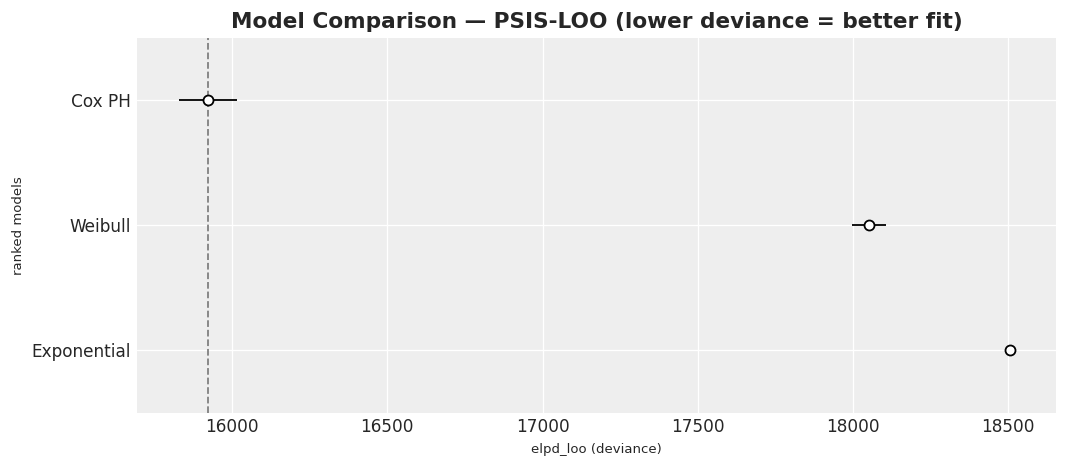

In [35]:
# ArviZ Compare Plot
# This requires all traces to have log_likelihood in the same variable name.
# ArviZ's compare function ranks models and shows the ELPD-LOO differences.

model_dict = {
    'Exponential': trace_exp,
    'Weibull':     trace_weibull,
    'Cox PH':      trace_cox,
}

comparison = az.compare(model_dict, ic='loo', scale='deviance')
print("\nArviZ Model Comparison (LOO):")
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
az.plot_compare(comparison, ax=ax)
ax.set_title('Model Comparison — PSIS-LOO (lower deviance = better fit)', fontweight='bold')
plt.tight_layout()
plt.show()

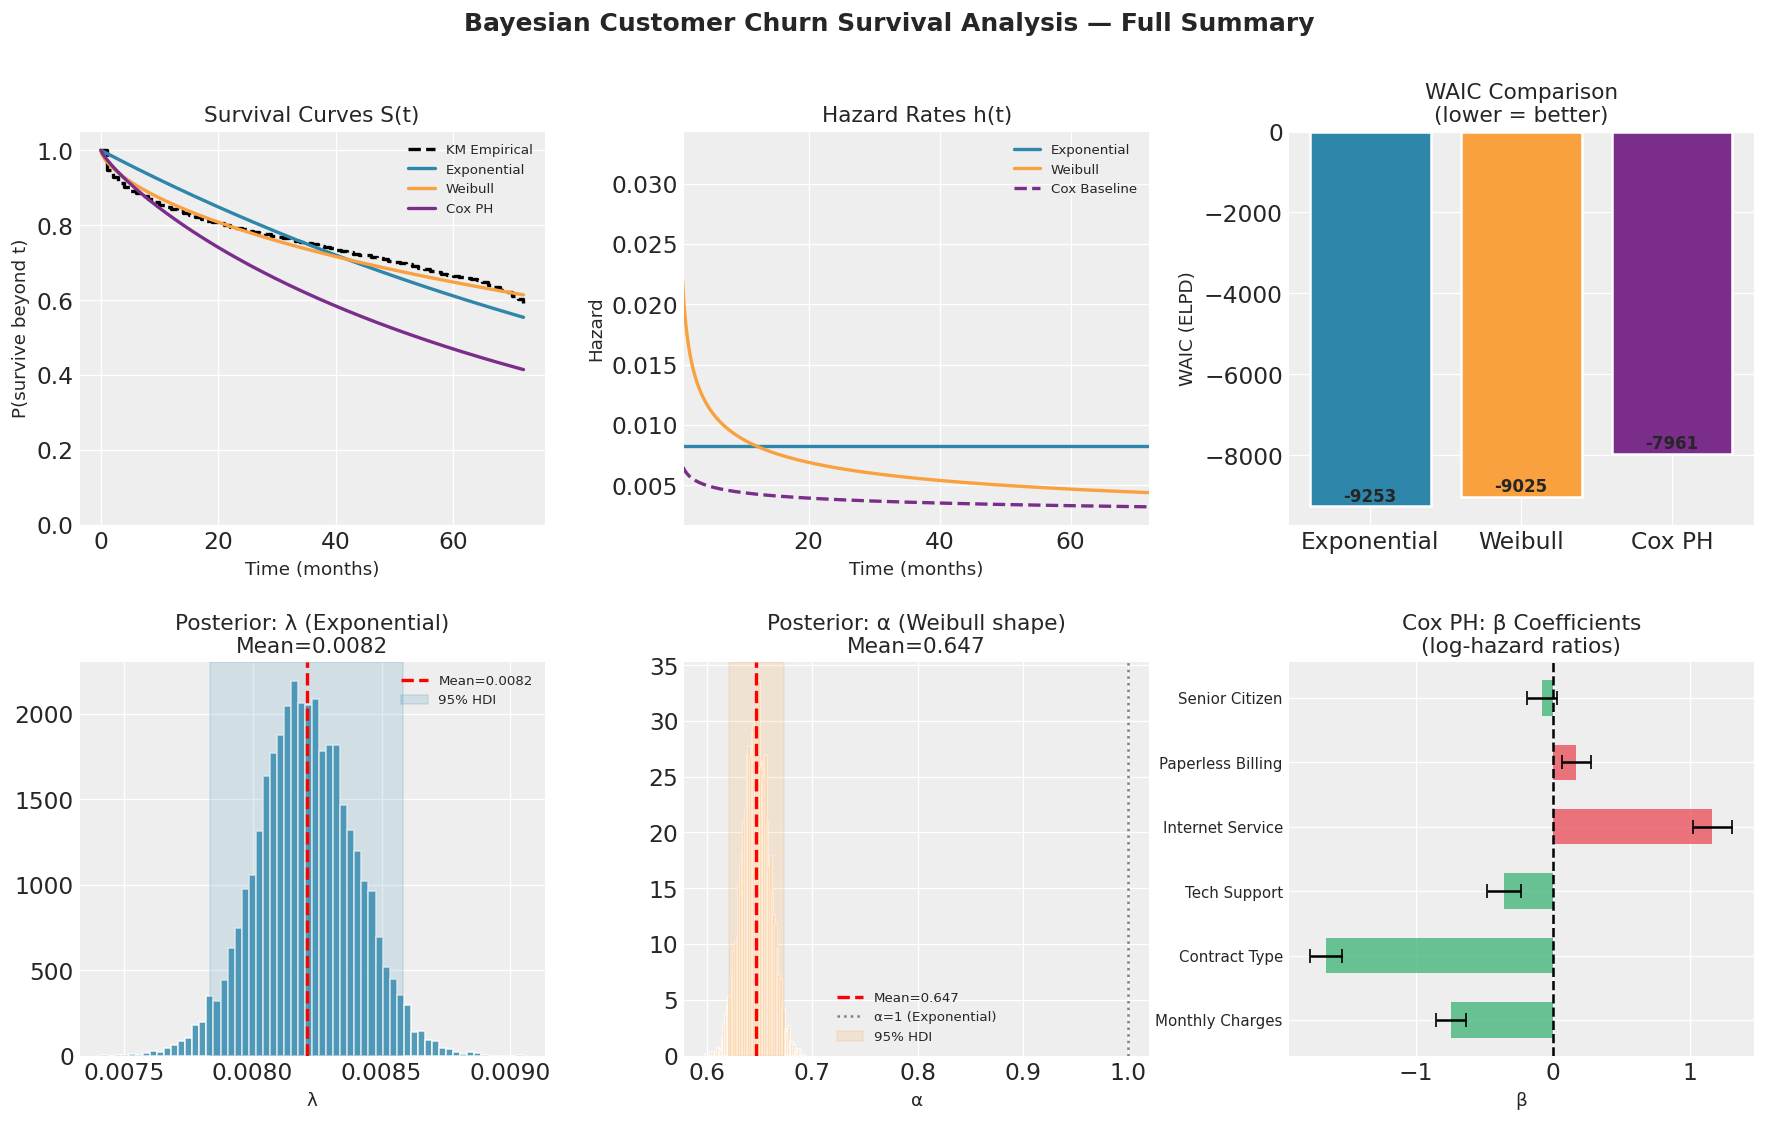

In [37]:
# Summary Visualization: All Outputs in One Figure
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)
fig.suptitle('Bayesian Customer Churn Survival Analysis — Full Summary',
             fontsize=15, fontweight='bold')

# Panel 1: Survival Curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.step(km_times, km_surv, where='post', color='black', lw=2, ls='--', label='KM Empirical')
for name, surv_mat, color in model_results:
    ax1.plot(t_grid, surv_mat.mean(axis=0), color=color, lw=2, label=name)
ax1.set_title('Survival Curves S(t)')
ax1.set_xlabel('Time (months)')
ax1.set_ylabel('P(survive beyond t)')
ax1.legend(fontsize=8)
ax1.set_ylim(0, 1.05)

#  Panel 2: Hazard Functions
ax2 = fig.add_subplot(gs[0, 1])
ax2.axhline(lam_mean, color=PALETTE[0], lw=2, label='Exponential')
ax2.plot(t_grid, hazard_weibull, color=PALETTE[3], lw=2, label='Weibull')
ax2.plot(t_grid, hazard_cox_baseline, color=PALETTE[4], lw=2, ls='--', label='Cox Baseline')
ax2.set_title('Hazard Rates h(t)')
ax2.set_xlabel('Time (months)')
ax2.set_ylabel('Hazard')
ax2.legend(fontsize=8)
ax2.set_xlim(1, 72)

# Panel 3: WAIC Comparison
ax3 = fig.add_subplot(gs[0, 2])
model_names = ['Exponential', 'Weibull', 'Cox PH']
waic_vals   = [waic_exp.elpd_waic, waic_weibull.elpd_waic, waic_cox.elpd_waic]
bar_colors  = [PALETTE[0], PALETTE[3], PALETTE[4]]
bars = ax3.bar(model_names, waic_vals, color=bar_colors, edgecolor='white', linewidth=1.5)
ax3.set_title('WAIC Comparison\n(lower = better)')
ax3.set_ylabel('WAIC (ELPD)')
for bar, val in zip(bars, waic_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 4: Posterior of λ (Exponential)
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(lam_samples, bins=60, color=PALETTE[0], alpha=0.8, density=True, edgecolor='white')
ax4.axvline(lam_samples.mean(), color='red', lw=2, ls='--', label=f'Mean={lam_samples.mean():.4f}')
lo4, hi4 = np.percentile(lam_samples, [2.5, 97.5])
ax4.axvspan(lo4, hi4, alpha=0.15, color=PALETTE[0], label='95% HDI')
ax4.set_title(f'Posterior: λ (Exponential)\nMean={lam_samples.mean():.4f}')
ax4.set_xlabel('λ')
ax4.legend(fontsize=8)

# Panel 5: Posterior of α (Weibull)
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(alpha_samples, bins=60, color=PALETTE[3], alpha=0.8, density=True, edgecolor='white')
ax5.axvline(alpha_samples.mean(), color='red', lw=2, ls='--', label=f'Mean={alpha_samples.mean():.3f}')
ax5.axvline(1.0, color='grey', lw=1.5, ls=':', label='α=1 (Exponential)')
lo5, hi5 = np.percentile(alpha_samples, [2.5, 97.5])
ax5.axvspan(lo5, hi5, alpha=0.15, color=PALETTE[3], label='95% HDI')
ax5.set_title(f'Posterior: α (Weibull shape)\nMean={alpha_samples.mean():.3f}')
ax5.set_xlabel('α')
ax5.legend(fontsize=8)

# Panel 6: Cox β Coefficients
ax6 = fig.add_subplot(gs[1, 2])
ax6.barh(np.arange(n_covs), beta_means, color=colors_b, alpha=0.75, height=0.55)
ax6.errorbar(beta_means, np.arange(n_covs),
             xerr=[beta_means - beta_lowers, beta_uppers - beta_means],
             fmt='none', color='black', capsize=4, lw=1.5)
ax6.axvline(0, color='black', lw=1.5, ls='--')
ax6.set_yticks(np.arange(n_covs))
ax6.set_yticklabels(covariate_names, fontsize=9)
ax6.set_title('Cox PH: β Coefficients\n(log-hazard ratios)')
ax6.set_xlabel('β')

plt.tight_layout()
plt.show()